In [1]:
# Intelligent Retail Inventory & Demand Forecasting System

print("Retail Inventory Project Started Successfully!")

Retail Inventory Project Started Successfully!


In [2]:
!pip install xgboost gradio openpyxl

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

from xgboost import XGBRegressor

print("All libraries imported successfully!")

All libraries imported successfully!


In [4]:
import pandas as pd
import numpy as np

# For same results every time
np.random.seed(42)

# Number of records
n = 1000

# Create dates
dates = pd.date_range(start="2025-01-01", periods=n, freq="D")

# Create dataset
data = {
    "Date": dates,
    "Store_ID": np.random.choice(
        ["Store_1", "Store_2", "Store_3", "Store_4", "Store_5"], n
    ),

    "Product_ID": np.random.choice(
        ["P001", "P002", "P003", "P004", "P005",
         "P006", "P007", "P008", "P009", "P010"], n
    ),

    "Product_Category": np.random.choice(
        ["Grocery", "Beverage", "Personal Care", "Pharmacy"], n
    ),

    "Sales": np.random.randint(20, 300, n),

    "Stock": np.random.randint(10, 500, n),

    "Price": np.random.randint(20, 1000, n),

    "Promotion": np.random.choice(["Yes", "No"], n),

    "Holiday": np.random.choice(["Yes", "No"], n),

    "Weather": np.random.choice(
        ["Sunny", "Rainy", "Cloudy", "Hot"], n
    ),

    "Local_Event": np.random.choice(
        ["Yes", "No"], n
    ),

    "Competitor_Price": np.random.randint(20, 1000, n),

    "Supplier_Lead_Time": np.random.randint(1, 15, n)
}

df = pd.DataFrame(data)

# Display first 10 rows
df.head(10)

,Date,Store_ID,Product_ID,Product_Category,Sales,Stock,Price,Promotion,Holiday,Weather,Local_Event,Competitor_Price,Supplier_Lead_Time
0,2025-01-01,Store_4,P004,Grocery,197,21,129,No,No,Rainy,Yes,608,3
1,2025-01-02,Store_5,P004,Personal Care,216,135,211,No,Yes,Rainy,Yes,485,1
2,2025-01-03,Store_3,P005,Grocery,286,62,923,Yes,No,Sunny,Yes,682,2
3,2025-01-04,Store_5,P008,Grocery,287,340,112,Yes,Yes,Rainy,No,465,6
4,2025-01-05,Store_5,P005,Personal Care,93,398,881,Yes,Yes,Sunny,Yes,769,12
5,2025-01-06,Store_2,P008,Personal Care,27,292,587,Yes,No,Hot,No,820,10
6,2025-01-07,Store_3,P010,Pharmacy,183,149,79,No,No,Rainy,Yes,762,2
7,2025-01-08,Store_3,P001,Pharmacy,104,410,669,No,Yes,Rainy,No,507,6
8,2025-01-09,Store_3,P010,Beverage,91,399,58,Yes,No,Cloudy,Yes,549,14
9,2025-01-10,Store_5,P009,Personal Care,74,106,559,Yes,Yes,Hot,Yes,92,1


In [5]:
# Check dataset information

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (1000, 13)

Column Names:
['Date', 'Store_ID', 'Product_ID', 'Product_Category', 'Sales', 'Stock', 'Price', 'Promotion', 'Holiday', 'Weather', 'Local_Event', 'Competitor_Price', 'Supplier_Lead_Time']

Missing Values:
Date                  0
Store_ID              0
Product_ID            0
Product_Category      0
Sales                 0
Stock                 0
Price                 0
Promotion             0
Holiday               0
Weather               0
Local_Event           0
Competitor_Price      0
Supplier_Lead_Time    0
dtype: int64

Data Types:
Date                  datetime64[ns]
Store_ID                      object
Product_ID                    object
Product_Category              object
Sales                          int64
Stock                          int64
Price                          int64
Promotion                     object
Holiday                       object
Weather                       object
Local_Event                   object
Competitor_Price       

In [6]:
# Make sure Date is in datetime format
df["Date"] = pd.to_datetime(df["Date"])

# Create date-based features
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["Day_of_Week"] = df["Date"].dt.dayofweek
df["Weekend"] = (df["Day_of_Week"] >= 5).astype(int)

# Display the updated dataset
print("New Shape:", df.shape)

df.head()

New Shape: (1000, 18)


,Date,Store_ID,Product_ID,Product_Category,Sales,Stock,Price,Promotion,Holiday,Weather,Local_Event,Competitor_Price,Supplier_Lead_Time,Year,Month,Day,Day_of_Week,Weekend
0,2025-01-01,Store_4,P004,Grocery,197,21,129,No,No,Rainy,Yes,608,3,2025,1,1,2,0
1,2025-01-02,Store_5,P004,Personal Care,216,135,211,No,Yes,Rainy,Yes,485,1,2025,1,2,3,0
2,2025-01-03,Store_3,P005,Grocery,286,62,923,Yes,No,Sunny,Yes,682,2,2025,1,3,4,0
3,2025-01-04,Store_5,P008,Grocery,287,340,112,Yes,Yes,Rainy,No,465,6,2025,1,4,5,1
4,2025-01-05,Store_5,P005,Personal Care,93,398,881,Yes,Yes,Sunny,Yes,769,12,2025,1,5,6,1


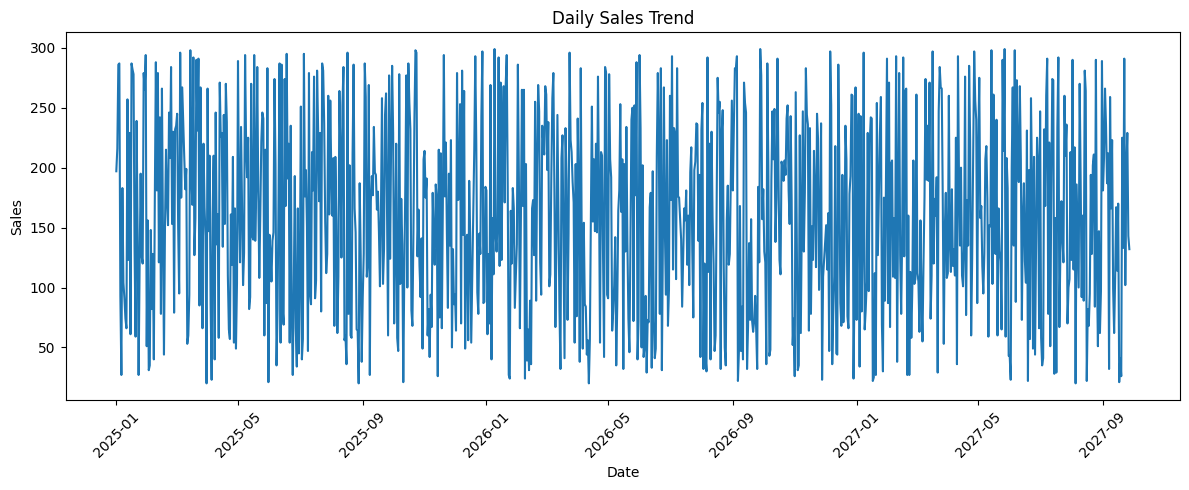

In [7]:
# Daily Sales Trend

plt.figure(figsize=(12, 5))

plt.plot(df["Date"], df["Sales"])

plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Daily Sales Trend")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

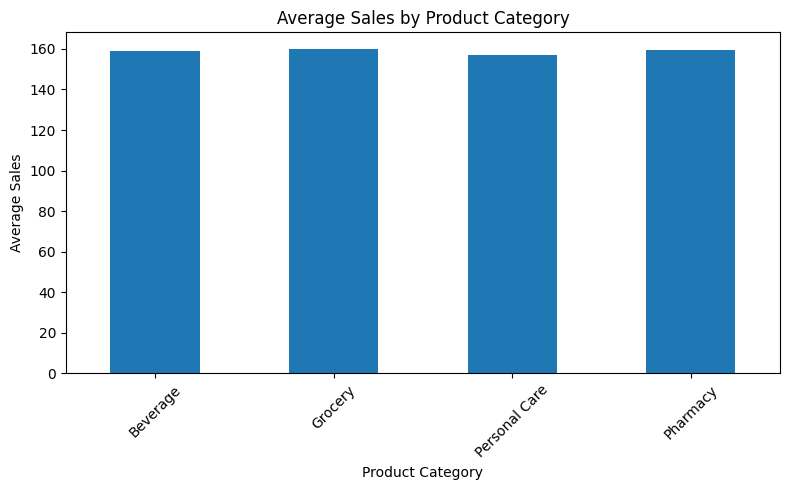

In [8]:
# Average Sales by Product Category

category_sales = df.groupby("Product_Category")["Sales"].mean()

plt.figure(figsize=(8, 5))

category_sales.plot(kind="bar")

plt.xlabel("Product Category")
plt.ylabel("Average Sales")
plt.title("Average Sales by Product Category")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [9]:
# Convert categorical columns into numerical values

df_encoded = pd.get_dummies(
    df,
    columns=[
        "Store_ID",
        "Product_ID",
        "Product_Category",
        "Promotion",
        "Holiday",
        "Weather",
        "Local_Event"
    ],
    drop_first=False
)

print("Original Shape:", df.shape)
print("Encoded Shape:", df_encoded.shape)

df_encoded.head()

Original Shape: (1000, 18)
Encoded Shape: (1000, 40)


,Date,Sales,Stock,Price,Competitor_Price,Supplier_Lead_Time,Year,Month,Day,Day_of_Week,...,Promotion_No,Promotion_Yes,Holiday_No,Holiday_Yes,Weather_Cloudy,Weather_Hot,Weather_Rainy,Weather_Sunny,Local_Event_No,Local_Event_Yes
0,2025-01-01,197,21,129,608,3,2025,1,1,2,...,True,False,True,False,False,False,True,False,False,True
1,2025-01-02,216,135,211,485,1,2025,1,2,3,...,True,False,False,True,False,False,True,False,False,True
2,2025-01-03,286,62,923,682,2,2025,1,3,4,...,False,True,True,False,False,False,False,True,False,True
3,2025-01-04,287,340,112,465,6,2025,1,4,5,...,False,True,False,True,False,False,True,False,True,False
4,2025-01-05,93,398,881,769,12,2025,1,5,6,...,False,True,False,True,False,False,False,True,False,True


In [10]:
# Select features for prediction

features = [
    "Stock",
    "Price",
    "Competitor_Price",
    "Supplier_Lead_Time",
    "Year",
    "Month",
    "Day",
    "Day_of_Week",
    "Weekend"
]

# Add encoded columns
encoded_features = [
    col for col in df_encoded.columns
    if col.startswith((
        "Store_ID_",
        "Product_ID_",
        "Product_Category_",
        "Promotion_",
        "Holiday_",
        "Weather_",
        "Local_Event_"
    ))
]

features = features + encoded_features

# Create X and Y
X = df_encoded[features]
Y = df_encoded["Sales"]

print("X Shape:", X.shape)
print("Y Shape:", Y.shape)

print("\nFeatures used for prediction:")
print(X.columns.tolist())

X Shape: (1000, 38)
Y Shape: (1000,)

Features used for prediction:
['Stock', 'Price', 'Competitor_Price', 'Supplier_Lead_Time', 'Year', 'Month', 'Day', 'Day_of_Week', 'Weekend', 'Store_ID_Store_1', 'Store_ID_Store_2', 'Store_ID_Store_3', 'Store_ID_Store_4', 'Store_ID_Store_5', 'Product_ID_P001', 'Product_ID_P002', 'Product_ID_P003', 'Product_ID_P004', 'Product_ID_P005', 'Product_ID_P006', 'Product_ID_P007', 'Product_ID_P008', 'Product_ID_P009', 'Product_ID_P010', 'Product_Category_Beverage', 'Product_Category_Grocery', 'Product_Category_Personal Care', 'Product_Category_Pharmacy', 'Promotion_No', 'Promotion_Yes', 'Holiday_No', 'Holiday_Yes', 'Weather_Cloudy', 'Weather_Hot', 'Weather_Rainy', 'Weather_Sunny', 'Local_Event_No', 'Local_Event_Yes']


In [11]:
# Split data into training and testing sets

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.20,
    random_state=42
)

print("Training data:")
print("X_train:", X_train.shape)
print("Y_train:", Y_train.shape)

print("\nTesting data:")
print("X_test:", X_test.shape)
print("Y_test:", Y_test.shape)

Training data:
X_train: (800, 38)
Y_train: (800,)

Testing data:
X_test: (200, 38)
Y_test: (200,)


In [12]:
# Create XGBoost model

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

# Train the model
xgb_model.fit(X_train, Y_train)

print("XGBoost model trained successfully!")

XGBoost model trained successfully!


In [13]:
# Predict sales using XGBoost

Y_pred_xgb = xgb_model.predict(X_test)

print("First 10 Actual Sales:")
print(Y_test.iloc[:10].values)

print("\nFirst 10 Predicted Sales:")
print(Y_pred_xgb[:10])

First 10 Actual Sales:
[ 51 296 105 194 173 130 157 288 173 294]

First 10 Predicted Sales:
[145.17567 168.00082 181.41698 224.7788  148.95934 154.7608  203.713
 144.1151  131.4588  168.26462]


In [14]:
# Evaluate XGBoost model

mae_xgb = mean_absolute_error(Y_test, Y_pred_xgb)

rmse_xgb = np.sqrt(mean_squared_error(Y_test, Y_pred_xgb))

print("XGBoost Model Performance")
print("--------------------------")
print("MAE  :", round(mae_xgb, 2))
print("RMSE :", round(rmse_xgb, 2))

XGBoost Model Performance
--------------------------
MAE  : 69.21
RMSE : 81.37


In [15]:
# Prepare sales data for LSTM

sales_data = df["Sales"].values.astype(float)

print("Total sales records:", len(sales_data))
print("First 10 sales values:")
print(sales_data[:10])

Total sales records: 1000
First 10 sales values:
[197. 216. 286. 287.  93.  27. 183. 104.  91.  74.]


In [16]:
# Create sequences for LSTM

sequence_length = 7

X_lstm = []
Y_lstm = []

for i in range(sequence_length, len(sales_data)):
    X_lstm.append(sales_data[i-sequence_length:i])
    Y_lstm.append(sales_data[i])

X_lstm = np.array(X_lstm)
Y_lstm = np.array(Y_lstm)

# Reshape for LSTM
X_lstm = X_lstm.reshape(
    X_lstm.shape[0],
    X_lstm.shape[1],
    1
)

print("LSTM Input Shape:", X_lstm.shape)
print("LSTM Target Shape:", Y_lstm.shape)

LSTM Input Shape: (993, 7, 1)
LSTM Target Shape: (993,)


In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Create LSTM model
lstm_model = Sequential([
    LSTM(50, activation="relu", input_shape=(7, 1)),
    Dense(1)
])

# Compile model
lstm_model.compile(
    optimizer="adam",
    loss="mse"
)

# Display model structure
lstm_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# Train the LSTM model

history = lstm_model.fit(
    X_lstm,
    Y_lstm,
    epochs=20,
    batch_size=32,
    verbose=1
)

print("LSTM model trained successfully!")

Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 12863.6104
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7358.2935
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7397.0469
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7340.9673
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7134.6904
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7027.0679
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7070.0537
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7235.3506
Epoch 9/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6905.0010
Epoch 10/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6859.0635
Epoch 11/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6906.7393
Epoch 12/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6751.2021
Epoch 13/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6696.8594
Epoch 14/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6718.4619
Epoch 15/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 

In [19]:
# Predict sales using LSTM

Y_pred_lstm = lstm_model.predict(X_lstm, verbose=0)

# Convert predictions to 1D array
Y_pred_lstm = Y_pred_lstm.flatten()

print("First 10 Actual Sales:")
print(Y_lstm[:10])

print("\nFirst 10 LSTM Predicted Sales:")
print(np.round(Y_pred_lstm[:10], 2))

First 10 Actual Sales:
[104.  91.  74.  66. 257. 123. 229.  61. 287. 282.]

First 10 LSTM Predicted Sales:
[175.76 145.1  115.87 156.52 152.71 151.46 147.66 156.43 157.95 168.65]


In [20]:
# Match XGBoost and LSTM predictions

xgb_pred = Y_pred_xgb[-200:]
lstm_pred = Y_pred_lstm[-200:]

actual_sales = Y_test.values

print("XGBoost predictions:", len(xgb_pred))
print("LSTM predictions:", len(lstm_pred))
print("Actual sales:", len(actual_sales))

XGBoost predictions: 200
LSTM predictions: 200
Actual sales: 200


In [21]:
# Combine XGBoost and LSTM predictions

xgb_weight = 0.5
lstm_weight = 0.5

final_demand_prediction = (
    xgb_weight * xgb_pred +
    lstm_weight * lstm_pred
)

print("First 10 Final Demand Predictions:")
print(np.round(final_demand_prediction[:10], 2))

First 10 Final Demand Predictions:
[154.14 166.79 171.36 196.53 152.93 173.91 189.74 159.03 148.6  159.94]


In [22]:
# Calculate safety stock

safety_stock = final_demand_prediction * 0.20

print("First 10 Safety Stock Values:")
print(np.round(safety_stock[:10], 2))

First 10 Safety Stock Values:
[30.83 33.36 34.27 39.31 30.59 34.78 37.95 31.81 29.72 31.99]


In [23]:
# Calculate reorder point

reorder_point = final_demand_prediction + safety_stock

print("First 10 Reorder Points:")
print(np.round(reorder_point[:10], 2))

First 10 Reorder Points:
[184.97 200.15 205.64 235.84 183.51 208.69 227.69 190.84 178.32 191.93]


In [24]:
# Get current stock for the test records

current_stock = X_test["Stock"].values

print("First 10 Current Stock Values:")
print(current_stock[:10])

First 10 Current Stock Values:
[148 239 273  11 471  70  73 422 467 159]


In [25]:
# Automatic reorder trigger

reorder_required = current_stock < reorder_point

print("First 10 Reorder Decisions:")
print(reorder_required[:10])

First 10 Reorder Decisions:
[ True False False  True False  True  True False False  True]


In [26]:
# Create reorder analysis table

reorder_df = pd.DataFrame({
    "Store_ID": df.loc[X_test.index, "Store_ID"].values,
    "Product_ID": df.loc[X_test.index, "Product_ID"].values,
    "Current_Stock": current_stock,
    "Predicted_Demand": np.round(final_demand_prediction, 2),
    "Safety_Stock": np.round(safety_stock, 2),
    "Reorder_Point": np.round(reorder_point, 2),
    "Supplier_Lead_Time": df.loc[X_test.index, "Supplier_Lead_Time"].values,
    "Reorder_Required": reorder_required
})

reorder_df.head(10)

,Store_ID,Product_ID,Current_Stock,Predicted_Demand,Safety_Stock,Reorder_Point,Supplier_Lead_Time,Reorder_Required
0,Store_1,P003,148,154.139999,30.830000,184.970001,8,True
1,Store_4,P009,239,166.789993,33.360001,200.149994,9,False
2,Store_2,P005,273,171.360001,34.270000,205.639999,3,False
3,Store_5,P007,11,196.529999,39.310001,235.839996,3,True
4,Store_2,P003,471,152.929993,30.590000,183.509995,9,False
5,Store_5,P003,70,173.910004,34.779999,208.690002,14,True
6,Store_4,P002,73,189.740005,37.950001,227.690002,10,True
7,Store_4,P002,422,159.029999,31.809999,190.839996,6,False
8,Store_3,P007,467,148.600006,29.719999,178.320007,1,False
9,Store_4,P010,159,159.940002,31.990000,191.929993,14,True


In [27]:
# Calculate suggested order quantity

reorder_df["Order_Quantity"] = np.maximum(
    reorder_df["Reorder_Point"] - reorder_df["Current_Stock"],
    0
).round().astype(int)

# Show products that need reordering
purchase_orders = reorder_df[
    reorder_df["Reorder_Required"] == True
].copy()

print("Total products requiring reorder:", len(purchase_orders))

purchase_orders.head(10)

Total products requiring reorder: 75


,Store_ID,Product_ID,Current_Stock,Predicted_Demand,Safety_Stock,Reorder_Point,Supplier_Lead_Time,Reorder_Required,Order_Quantity
0,Store_1,P003,148,154.139999,30.830000,184.970001,8,True,37
3,Store_5,P007,11,196.529999,39.310001,235.839996,3,True,225
5,Store_5,P003,70,173.910004,34.779999,208.690002,14,True,139
6,Store_4,P002,73,189.740005,37.950001,227.690002,10,True,155
9,Store_4,P010,159,159.940002,31.990000,191.929993,14,True,33
10,Store_2,P007,162,157.460007,31.490000,188.949997,1,True,27
11,Store_1,P001,80,183.460007,36.689999,220.149994,10,True,140
12,Store_1,P007,179,161.279999,32.259998,193.529999,1,True,15
16,Store_2,P003,27,162.110001,32.419998,194.529999,2,True,168
18,Store_3,P009,172,172.000000,34.400002,206.399994,11,True,34


In [28]:
# Create final purchase order table

purchase_order = purchase_orders[
    [
        "Store_ID",
        "Product_ID",
        "Current_Stock",
        "Predicted_Demand",
        "Reorder_Point",
        "Order_Quantity",
        "Supplier_Lead_Time"
    ]
].reset_index(drop=True)

print("PURCHASE ORDER")
print("=" * 50)

purchase_order.head(20)

PURCHASE ORDER


,Store_ID,Product_ID,Current_Stock,Predicted_Demand,Reorder_Point,Order_Quantity,Supplier_Lead_Time
0,Store_1,P003,148,154.139999,184.970001,37,8
1,Store_5,P007,11,196.529999,235.839996,225,3
2,Store_5,P003,70,173.910004,208.690002,139,14
3,Store_4,P002,73,189.740005,227.690002,155,10
4,Store_4,P010,159,159.940002,191.929993,33,14
5,Store_2,P007,162,157.460007,188.949997,27,1
6,Store_1,P001,80,183.460007,220.149994,140,10
7,Store_1,P007,179,161.279999,193.529999,15,1
8,Store_2,P003,27,162.110001,194.529999,168,2
9,Store_3,P009,172,172.000000,206.399994,34,11


In [29]:
# Analyze product-wise sales and stock

product_analysis = df.groupby("Product_ID").agg({
    "Sales": "mean",
    "Stock": "mean"
}).reset_index()

product_analysis.columns = [
    "Product_ID",
    "Average_Sales",
    "Average_Stock"
]

product_analysis

,Product_ID,Average_Sales,Average_Stock
0,P001,155.676190,280.400000
1,P002,161.920354,268.584071
2,P003,164.705263,256.747368
3,P004,156.471264,230.000000
4,P005,162.415842,237.960396
5,P006,154.864583,267.937500
6,P007,164.343434,258.262626
7,P008,155.565657,252.898990
8,P009,153.310680,255.019417
9,P010,160.156863,253.117647


In [30]:
# Identify dead stock

product_analysis["Dead_Stock"] = (
    (product_analysis["Average_Sales"] < 100) &
    (product_analysis["Average_Stock"] > 250)
)

print("Dead Stock Analysis:")
print(product_analysis)

Dead Stock Analysis:
  Product_ID  Average_Sales  Average_Stock  Dead_Stock
0       P001     155.676190     280.400000       False
1       P002     161.920354     268.584071       False
2       P003     164.705263     256.747368       False
3       P004     156.471264     230.000000       False
4       P005     162.415842     237.960396       False
5       P006     154.864583     267.937500       False
6       P007     164.343434     258.262626       False
7       P008     155.565657     252.898990       False
8       P009     153.310680     255.019417       False
9       P010     160.156863     253.117647       False


In [31]:
# Suggest discount action

def discount_suggestion(is_dead_stock):
    if is_dead_stock:
        return "Suggest 20% Discount"
    else:
        return "No Discount Needed"

product_analysis["Discount_Action"] = product_analysis[
    "Dead_Stock"
].apply(discount_suggestion)

product_analysis

,Product_ID,Average_Sales,Average_Stock,Dead_Stock,Discount_Action
0,P001,155.676190,280.400000,False,No Discount Needed
1,P002,161.920354,268.584071,False,No Discount Needed
2,P003,164.705263,256.747368,False,No Discount Needed
3,P004,156.471264,230.000000,False,No Discount Needed
4,P005,162.415842,237.960396,False,No Discount Needed
5,P006,154.864583,267.937500,False,No Discount Needed
6,P007,164.343434,258.262626,False,No Discount Needed
7,P008,155.565657,252.898990,False,No Discount Needed
8,P009,153.310680,255.019417,False,No Discount Needed
9,P010,160.156863,253.117647,False,No Discount Needed


In [32]:
# Create realistic dead-stock scenarios

dead_stock_products = ["P009", "P010"]

df.loc[
    df["Product_ID"].isin(dead_stock_products),
    "Sales"
] = np.random.randint(20, 70, size=df["Product_ID"].isin(dead_stock_products).sum())

df.loc[
    df["Product_ID"].isin(dead_stock_products),
    "Stock"
] = np.random.randint(300, 500, size=df["Product_ID"].isin(dead_stock_products).sum())

print("Dead-stock scenarios created successfully!")

Dead-stock scenarios created successfully!


In [33]:
product_analysis = df.groupby("Product_ID").agg({
    "Sales": "mean",
    "Stock": "mean"
}).reset_index()

product_analysis.columns = [
    "Product_ID",
    "Average_Sales",
    "Average_Stock"
]

product_analysis["Dead_Stock"] = (
    (product_analysis["Average_Sales"] < 100) &
    (product_analysis["Average_Stock"] > 250)
)

product_analysis["Discount_Action"] = product_analysis[
    "Dead_Stock"
].apply(discount_suggestion)

print("Dead Stock Analysis:")
display(product_analysis)

Dead Stock Analysis:


,Product_ID,Average_Sales,Average_Stock,Dead_Stock,Discount_Action
0,P001,155.676190,280.400000,False,No Discount Needed
1,P002,161.920354,268.584071,False,No Discount Needed
2,P003,164.705263,256.747368,False,No Discount Needed
3,P004,156.471264,230.000000,False,No Discount Needed
4,P005,162.415842,237.960396,False,No Discount Needed
5,P006,154.864583,267.937500,False,No Discount Needed
6,P007,164.343434,258.262626,False,No Discount Needed
7,P008,155.565657,252.898990,False,No Discount Needed
8,P009,44.174757,397.271845,True,Suggest 20% Discount
9,P010,44.676471,400.215686,True,Suggest 20% Discount


In [34]:
# Step 11.1 - Prepare data for Supplier Lead Time Prediction

lead_time_features = [
    "Stock",
    "Price",
    "Competitor_Price",
    "Sales",
    "Promotion",
    "Holiday",
    "Weather",
    "Local_Event"
]

lead_df = df[lead_time_features + ["Supplier_Lead_Time"]].copy()

# Convert categorical columns into numbers
lead_df = pd.get_dummies(
    lead_df,
    columns=[
        "Promotion",
        "Holiday",
        "Weather",
        "Local_Event"
    ],
    drop_first=False
)

print("Lead Time Dataset Shape:", lead_df.shape)
print("\nLead Time Features:")
print(lead_df.columns.tolist())

Lead Time Dataset Shape: (1000, 15)

Lead Time Features:
['Stock', 'Price', 'Competitor_Price', 'Sales', 'Supplier_Lead_Time', 'Promotion_No', 'Promotion_Yes', 'Holiday_No', 'Holiday_Yes', 'Weather_Cloudy', 'Weather_Hot', 'Weather_Rainy', 'Weather_Sunny', 'Local_Event_No', 'Local_Event_Yes']


In [35]:
# Step 11.2 - Separate features and target

X_lead = lead_df.drop("Supplier_Lead_Time", axis=1)
Y_lead = lead_df["Supplier_Lead_Time"]

print("X Lead Shape:", X_lead.shape)
print("Y Lead Shape:", Y_lead.shape)

X Lead Shape: (1000, 14)
Y Lead Shape: (1000,)


In [36]:
# Step 11.3 - Train/Test Split for Lead Time

X_lead_train, X_lead_test, Y_lead_train, Y_lead_test = train_test_split(
    X_lead,
    Y_lead,
    test_size=0.20,
    random_state=42
)

print("Training Data:", X_lead_train.shape)
print("Testing Data :", X_lead_test.shape)

Training Data: (800, 14)
Testing Data : (200, 14)


In [37]:
# Step 11.4 - Supplier Lead Time Prediction Model

lead_time_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

lead_time_model.fit(
    X_lead_train,
    Y_lead_train
)

print("Supplier Lead Time Model Trained Successfully!")

Supplier Lead Time Model Trained Successfully!


In [38]:
# Step 11.5 - Predict Supplier Lead Time

Y_lead_pred = lead_time_model.predict(X_lead_test)

print("Actual Lead Time (First 10):")
print(Y_lead_test.iloc[:10].values)

print("\nPredicted Lead Time (First 10):")
print(np.round(Y_lead_pred[:10], 2))

Actual Lead Time (First 10):
[ 8  9  3  3  9 14 10  6  1 14]

Predicted Lead Time (First 10):
[ 8.03  6.81  8.77 10.12  7.72  8.01  7.32  7.95  7.32  6.86]


In [39]:
# Step 11.6 - Evaluate Supplier Lead Time Model

mae_lead = mean_absolute_error(Y_lead_test, Y_lead_pred)
rmse_lead = np.sqrt(mean_squared_error(Y_lead_test, Y_lead_pred))

print("Supplier Lead Time Model Performance")
print("------------------------------------")
print("MAE  :", round(mae_lead, 2))
print("RMSE :", round(rmse_lead, 2))

Supplier Lead Time Model Performance
------------------------------------
MAE  : 3.84
RMSE : 4.37


In [40]:
# Step 12.1 - Add Predicted Lead Time

reorder_with_lead = reorder_df.copy()

reorder_with_lead["Predicted_Lead_Time"] = np.round(
    Y_lead_pred
).astype(int)

print("Reorder Data with Predicted Lead Time:")
display(reorder_with_lead.head(10))

Reorder Data with Predicted Lead Time:


,Store_ID,Product_ID,Current_Stock,Predicted_Demand,Safety_Stock,Reorder_Point,Supplier_Lead_Time,Reorder_Required,Order_Quantity,Predicted_Lead_Time
0,Store_1,P003,148,154.139999,30.830000,184.970001,8,True,37,8
1,Store_4,P009,239,166.789993,33.360001,200.149994,9,False,0,7
2,Store_2,P005,273,171.360001,34.270000,205.639999,3,False,0,9
3,Store_5,P007,11,196.529999,39.310001,235.839996,3,True,225,10
4,Store_2,P003,471,152.929993,30.590000,183.509995,9,False,0,8
5,Store_5,P003,70,173.910004,34.779999,208.690002,14,True,139,8
6,Store_4,P002,73,189.740005,37.950001,227.690002,10,True,155,7
7,Store_4,P002,422,159.029999,31.809999,190.839996,6,False,0,8
8,Store_3,P007,467,148.600006,29.719999,178.320007,1,False,0,7
9,Store_4,P010,159,159.940002,31.990000,191.929993,14,True,33,7


In [41]:
# Step 12.2 - Smart Reorder Quantity using Lead Time

reorder_with_lead["Lead_Time_Demand"] = (
    reorder_with_lead["Predicted_Demand"] *
    reorder_with_lead["Predicted_Lead_Time"] / 7
)

reorder_with_lead["Smart_Reorder_Point"] = (
    reorder_with_lead["Lead_Time_Demand"] +
    reorder_with_lead["Safety_Stock"]
)

reorder_with_lead["Smart_Order_Quantity"] = np.maximum(
    reorder_with_lead["Smart_Reorder_Point"] -
    reorder_with_lead["Current_Stock"],
    0
).round().astype(int)

reorder_with_lead["Smart_Reorder_Required"] = (
    reorder_with_lead["Current_Stock"] <
    reorder_with_lead["Smart_Reorder_Point"]
)

print("Smart Reorder Analysis:")
display(
    reorder_with_lead[
        [
            "Store_ID",
            "Product_ID",
            "Current_Stock",
            "Predicted_Demand",
            "Predicted_Lead_Time",
            "Smart_Reorder_Point",
            "Smart_Order_Quantity",
            "Smart_Reorder_Required"
        ]
    ].head(10)
)

Smart Reorder Analysis:


,Store_ID,Product_ID,Current_Stock,Predicted_Demand,Predicted_Lead_Time,Smart_Reorder_Point,Smart_Order_Quantity,Smart_Reorder_Required
0,Store_1,P003,148,154.139999,8,206.989999,59,True
1,Store_4,P009,239,166.789993,7,200.149994,0,False
2,Store_2,P005,273,171.360001,9,254.590001,0,False
3,Store_5,P007,11,196.529999,10,320.067142,309,True
4,Store_2,P003,471,152.929993,8,205.367135,0,False
5,Store_5,P003,70,173.910004,8,233.534289,164,True
6,Store_4,P002,73,189.740005,7,227.690006,155,True
7,Store_4,P002,422,159.029999,8,213.558569,0,False
8,Store_3,P007,467,148.600006,7,178.320005,0,False
9,Store_4,P010,159,159.940002,7,191.930002,33,True


In [42]:
# Step 13 - Combined Inventory Alert System

# Add dead-stock information
dead_stock_map = product_analysis.set_index("Product_ID")["Dead_Stock"].to_dict()

reorder_with_lead["Dead_Stock"] = reorder_with_lead[
    "Product_ID"
].map(dead_stock_map).fillna(False)

def inventory_action(row):
    if row["Dead_Stock"]:
        return "DEAD STOCK - Suggest 20% Discount"
    elif row["Smart_Reorder_Required"]:
        return "LOW STOCK - Reorder Required"
    else:
        return "NORMAL - No Action"

reorder_with_lead["Inventory_Action"] = reorder_with_lead.apply(
    inventory_action,
    axis=1
)

print("Combined Inventory Alerts:")
display(
    reorder_with_lead[
        [
            "Store_ID",
            "Product_ID",
            "Current_Stock",
            "Predicted_Demand",
            "Smart_Order_Quantity",
            "Dead_Stock",
            "Inventory_Action"
        ]
    ].head(15)
)

Combined Inventory Alerts:


,Store_ID,Product_ID,Current_Stock,Predicted_Demand,Smart_Order_Quantity,Dead_Stock,Inventory_Action
0,Store_1,P003,148,154.139999,59,False,LOW STOCK - Reorder Required
1,Store_4,P009,239,166.789993,0,True,DEAD STOCK - Suggest 20% Discount
2,Store_2,P005,273,171.360001,0,False,NORMAL - No Action
3,Store_5,P007,11,196.529999,309,False,LOW STOCK - Reorder Required
4,Store_2,P003,471,152.929993,0,False,NORMAL - No Action
5,Store_5,P003,70,173.910004,164,False,LOW STOCK - Reorder Required
6,Store_4,P002,73,189.740005,155,False,LOW STOCK - Reorder Required
7,Store_4,P002,422,159.029999,0,False,NORMAL - No Action
8,Store_3,P007,467,148.600006,0,False,NORMAL - No Action
9,Store_4,P010,159,159.940002,33,True,DEAD STOCK - Suggest 20% Discount


In [43]:
# Step 14 - Head Office Dashboard KPIs

total_records = len(reorder_with_lead)

reorder_alerts = (
    reorder_with_lead["Smart_Reorder_Required"] == True
).sum()

dead_stock_alerts = (
    reorder_with_lead["Dead_Stock"] == True
).sum()

total_order_quantity = reorder_with_lead[
    "Smart_Order_Quantity"
].sum()

normal_items = (
    (reorder_with_lead["Dead_Stock"] == False) &
    (reorder_with_lead["Smart_Reorder_Required"] == False)
).sum()

print("====================================")
print("   HEAD OFFICE INVENTORY DASHBOARD")
print("====================================")
print("Total Records Monitored :", total_records)
print("Reorder Alerts          :", reorder_alerts)
print("Dead Stock Alerts       :", dead_stock_alerts)
print("Normal Items            :", normal_items)
print("Total Units to Order    :", total_order_quantity)
print("====================================")

   HEAD OFFICE INVENTORY DASHBOARD
Total Records Monitored : 200
Reorder Alerts          : 77
Dead Stock Alerts       : 54
Normal Items            : 90
Total Units to Order    : 7778


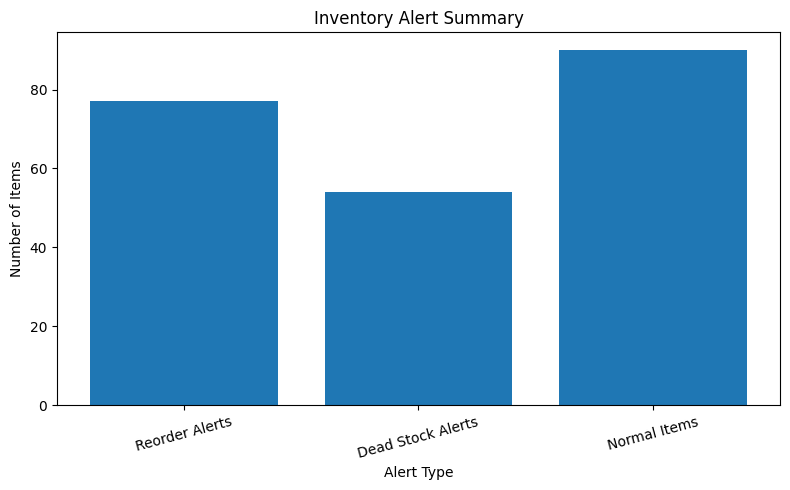

In [44]:
# Step 14.1 - Inventory Alert Visualization

alert_counts = {
    "Reorder Alerts": reorder_alerts,
    "Dead Stock Alerts": dead_stock_alerts,
    "Normal Items": normal_items
}

plt.figure(figsize=(8, 5))

plt.bar(
    alert_counts.keys(),
    alert_counts.values()
)

plt.title("Inventory Alert Summary")
plt.xlabel("Alert Type")
plt.ylabel("Number of Items")

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [45]:
# Step 15.1 - Store Manager Alert Function

def store_manager_alert(product_id):

    data = reorder_with_lead[
        reorder_with_lead["Product_ID"] == product_id
    ]

    if data.empty:
        return "Product not found."

    row = data.iloc[0]

    result = f"""
STORE MANAGER INVENTORY ALERT
-----------------------------

Product ID          : {row['Product_ID']}
Store ID            : {row['Store_ID']}

Current Stock       : {row['Current_Stock']} units
Predicted Demand    : {row['Predicted_Demand']:.2f} units
Supplier Lead Time  : {row['Predicted_Lead_Time']} days

Smart Order Qty     : {row['Smart_Order_Quantity']} units

Inventory Status    : {row['Inventory_Action']}
"""

    return result

print(store_manager_alert("P009"))


STORE MANAGER INVENTORY ALERT
-----------------------------

Product ID          : P009
Store ID            : Store_4

Current Stock       : 239 units
Predicted Demand    : 166.79 units
Supplier Lead Time  : 7 days

Smart Order Qty     : 0 units

Inventory Status    : DEAD STOCK - Suggest 20% Discount



In [46]:
# Step 15.2 - Store Manager Alert App

import gradio as gr

product_list = sorted(
    reorder_with_lead["Product_ID"].unique().tolist()
)

def get_inventory_alert(product_id):
    return store_manager_alert(product_id)

with gr.Blocks(title="Store Manager Inventory App") as store_app:

    gr.Markdown(
        """
        # 📦 Store Manager Inventory App
        ### Intelligent Retail Inventory & Demand Forecasting System
        """
    )

    product_dropdown = gr.Dropdown(
        choices=product_list,
        label="Select Product",
        value=product_list[0]
    )

    check_button = gr.Button(
        "🔍 Check Inventory"
    )

    output_box = gr.Textbox(
        label="Inventory Alert",
        lines=12
    )

    check_button.click(
        fn=get_inventory_alert,
        inputs=product_dropdown,
        outputs=output_box
    )

store_app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://89b8316e011b149b4d.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [47]:
# Step 16.1 - Final Inventory Dashboard

import gradio as gr

def dashboard_summary():

    total_items = len(reorder_with_lead)

    reorder_items = (
        reorder_with_lead["Smart_Reorder_Required"] == True
    ).sum()

    dead_items = (
        reorder_with_lead["Dead_Stock"] == True
    ).sum()

    normal_items = (
        (reorder_with_lead["Dead_Stock"] == False) &
        (reorder_with_lead["Smart_Reorder_Required"] == False)
    ).sum()

    total_order = reorder_with_lead[
        "Smart_Order_Quantity"
    ].sum()

    return f"""
# 🏢 Head Office Inventory Dashboard

### 📊 Inventory Summary

**Total Items Monitored:** {total_items}

**🔔 Reorder Alerts:** {reorder_items}

**💤 Dead Stock Alerts:** {dead_items}

**✅ Normal Items:** {normal_items}

**🛒 Total Units Recommended for Order:** {total_order}

---

### 🤖 Intelligent System Decisions

🔴 **Low Stock** → Reorder Required

🟡 **Dead Stock** → Suggest 20% Discount

🟢 **Normal Stock** → No Action

---

### 🚚 Supplier Management

The system uses predicted supplier lead time to calculate
a smarter reorder point and recommended order quantity.

### 📈 Demand Forecasting

Demand is predicted using an **XGBoost + LSTM ensemble model**.
"""

with gr.Blocks(
    title="Intelligent Retail Inventory Dashboard"
) as dashboard:

    gr.Markdown(
        """
        # 🏪 Intelligent Retail Inventory & Demand Forecasting System
        ### Head Office Dashboard
        """
    )

    show_button = gr.Button(
        "📊 Show Dashboard"
    )

    output = gr.Markdown()

    show_button.click(
        fn=dashboard_summary,
        inputs=[],
        outputs=output
    )

dashboard.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://dfac53b0d3fc29a16b.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [48]:
# Step 16.2 - Product-wise Inventory Details

def product_details(product_id):

    data = reorder_with_lead[
        reorder_with_lead["Product_ID"] == product_id
    ]

    if data.empty:
        return "Product not found."

    row = data.iloc[0]

    return f"""
## 📦 Product Inventory Details

**Product ID:** {row['Product_ID']}

**Store ID:** {row['Store_ID']}

**Current Stock:** {row['Current_Stock']} units

**Predicted Demand:** {row['Predicted_Demand']:.2f} units

**Predicted Supplier Lead Time:** {row['Predicted_Lead_Time']} days

**Smart Reorder Point:** {row['Smart_Reorder_Point']:.2f} units

**Recommended Order Quantity:** {row['Smart_Order_Quantity']} units

### 🔔 Inventory Action
**{row['Inventory_Action']}**
"""

product_choices = sorted(
    reorder_with_lead["Product_ID"].unique().tolist()
)

with gr.Blocks(
    title="Product Inventory Details"
) as product_app:

    gr.Markdown(
        """
        # 📦 Product-wise Inventory Details
        """
    )

    product_select = gr.Dropdown(
        choices=product_choices,
        label="Select Product",
        value=product_choices[0]
    )

    view_button = gr.Button(
        "🔍 View Product Details"
    )

    details_output = gr.Markdown()

    view_button.click(
        fn=product_details,
        inputs=product_select,
        outputs=details_output
    )

product_app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7d640cee51179ddbbf.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [49]:
# Step 16.3 - Final Integrated Inventory App

import gradio as gr

product_choices = sorted(
    reorder_with_lead["Product_ID"].unique().tolist()
)

def final_product_details(product_id):

    data = reorder_with_lead[
        reorder_with_lead["Product_ID"] == product_id
    ]

    if data.empty:
        return "Product not found."

    row = data.iloc[0]

    return f"""
## 📦 Product Details

**Product ID:** {row['Product_ID']}

**Store ID:** {row['Store_ID']}

**Current Stock:** {row['Current_Stock']} units

**Predicted Demand:** {row['Predicted_Demand']:.2f} units

**Safety Stock:** {row['Safety_Stock']:.2f} units

**Predicted Lead Time:** {row['Predicted_Lead_Time']} days

**Smart Reorder Point:** {row['Smart_Reorder_Point']:.2f} units

**Recommended Order Quantity:** {row['Smart_Order_Quantity']} units

### 🔔 Inventory Status

**{row['Inventory_Action']}**
"""


def final_dashboard():

    total_items = len(reorder_with_lead)

    reorder_items = (
        reorder_with_lead["Smart_Reorder_Required"] == True
    ).sum()

    dead_items = (
        reorder_with_lead["Dead_Stock"] == True
    ).sum()

    normal_items = (
        (reorder_with_lead["Dead_Stock"] == False) &
        (reorder_with_lead["Smart_Reorder_Required"] == False)
    ).sum()

    total_order = reorder_with_lead[
        "Smart_Order_Quantity"
    ].sum()

    return f"""
# 🏪 Intelligent Retail Inventory & Demand Forecasting System

## 🏢 Head Office Dashboard

| Metric | Value |
|---|---:|
| 📊 Total Items Monitored | **{total_items}** |
| 🔔 Reorder Alerts | **{reorder_items}** |
| 💤 Dead Stock Alerts | **{dead_items}** |
| ✅ Normal Items | **{normal_items}** |
| 🛒 Total Units to Order | **{total_order}** |

---

## 🤖 Intelligent Decisions

🔴 **Low Stock** → Reorder Required

🟡 **Dead Stock** → Suggest 20% Discount

🟢 **Normal Stock** → No Action

---

### 🧠 AI Forecasting

**XGBoost + LSTM Ensemble**

The system predicts product demand and uses supplier
lead time and safety stock to calculate a smart reorder point.

### 🚚 Supplier Management

Predicted supplier lead time is considered before
generating the recommended order quantity.
"""


with gr.Blocks(
    title="Intelligent Retail Inventory System"
) as final_app:

    gr.Markdown(
        """
        # 🏪 Intelligent Retail Inventory & Demand Forecasting
        ### AI-Powered Smart Inventory Management System
        """
    )

    gr.Markdown(
        """
        ## 🏢 Head Office Dashboard
        """
    )

    dashboard_button = gr.Button(
        "📊 Generate Dashboard Summary"
    )

    dashboard_output = gr.Markdown()

    dashboard_button.click(
        fn=final_dashboard,
        inputs=[],
        outputs=dashboard_output
    )

    gr.Markdown(
        """
        ---
        ## 📦 Product-wise Inventory Analysis
        """
    )

    product_dropdown = gr.Dropdown(
        choices=product_choices,
        label="Select Product",
        value=product_choices[0]
    )

    product_button = gr.Button(
        "🔍 Check Product Inventory"
    )

    product_output = gr.Markdown()

    product_button.click(
        fn=final_product_details,
        inputs=product_dropdown,
        outputs=product_output
    )


final_app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ceac8a66d6a753816f.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
